# EarthCARE/tracking colocation

Example of working with colocated DCCs and EarthCARE overpasses

In [10]:
import pathlib
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

In [2]:
data_path = pathlib.Path("/gws/ssde/j25a/aopp/wkjones/orcestra_case_study/")

In [3]:
tracking_mask_path = data_path / "orcestra_linked"
overpass_path = data_path / "ec_track_overpasses"
anvils_path = data_path / "ec_anvil_overpasses"

### Tracked DCC masks
One file per day, which include data for core, thick and thin anvil masks

In [5]:
tracking_mask_files = sorted(list(tracking_mask_path.rglob("detected_dccs_*.nc")))

In [7]:
mask_ds = xr.open_dataset(tracking_mask_files[8])

/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'datamet' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
 

In [8]:
mask_ds

<xarray.Dataset> Size: 19GB
Dimensions:                       (y: 2287, x: 3623, t: 96, core: 2541,
                                   anvil: 1720, core_step: 11230,
                                   thick_anvil_step: 29326,
                                   thin_anvil_step: 32808)
Coordinates:
  * t                             (t) datetime64[ns] 768B 2024-08-18T00:12:43...
  * y                             (y) float64 18kB -3.429e+06 ... 3.429e+06
  * x                             (x) float64 29kB 5.434e+06 ... -5.434e+06
    longitude                     (y, x) float64 66MB ...
    latitude                      (y, x) float64 66MB ...
  * core                          (core) int32 10kB 27858 27862 ... 30466 30467
  * anvil                         (anvil) int32 7kB 11702 11709 ... 13958 13964
  * core_step                     (core_step) int32 45kB 1 2 3 ... 11229 11230
  * thick_anvil_step              (thick_anvil_step) int32 117kB 1 2 ... 29326
  * thin_anvil_step               (thin_anvil_step) int32 131kB 1 2 ... 32808
Data variables: (12/77)
    lat                           (y, x) float32 33MB ...
    lon                           (y, x) float32 33MB ...
    area                          (y, x) float32 33MB ...
    core_label                    (t, y, x) int32 3GB ...
    thick_anvil_label             (t, y, x) int32 3GB ...
    thin_anvil_label              (t, y, x) int32 3GB ...
    ...                            ...
    thick_anvil_step_bt_max       (thick_anvil_step) float32 117kB ...
    thick_anvil_step_bt_min       (thick_anvil_step) float32 117kB ...
    thin_anvil_step_bt_mean       (thin_anvil_step) float32 131kB ...
    thin_anvil_step_bt_std        (thin_anvil_step) float32 131kB ...
    thin_anvil_step_bt_max        (thin_anvil_step) float32 131kB ...
    thin_anvil_step_bt_min        (thin_anvil_step) float32 131kB ...

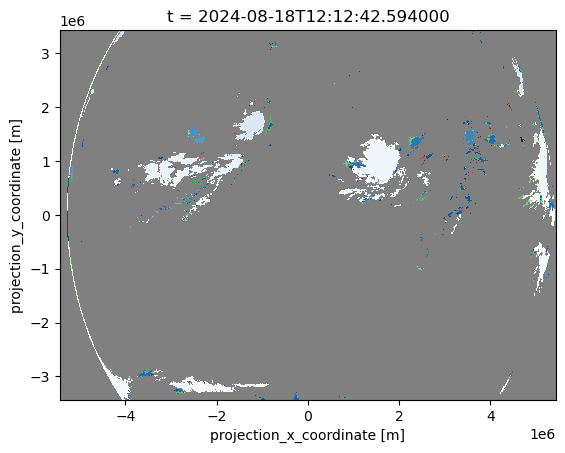

In [14]:
fig, ax = plt.subplots(1,1)
ax.set_facecolor("grey")
mask_ds.thin_anvil_label[48].where(mask_ds.thin_anvil_label[48]!=0).plot(ax=ax, cmap="Greens", add_colorbar=False)
mask_ds.thick_anvil_label[48].where(mask_ds.thick_anvil_label[48]!=0).plot(ax=ax, cmap="Blues", add_colorbar=False)
mask_ds.core_label[48].where(mask_ds.core_label[48]!=0).plot(ax=ax, cmap="Reds", add_colorbar=False)

The masks are in the native MSG projection x/y coordinates, but also have latitude/longitude values,

## Aggregated DCC properties
The combined DCC properties across the entire tracking period are contained in the stats file. This file contains bulk properties for each track core and anvil, along with the locations and properties at each time step. These can be used to understand the evolution of different systems

In [15]:
stats_file = list(data_path.glob("*_S20240810*"))[0]
stats_ds = xr.open_dataset(stats_file)

In [16]:
stats_ds

<xarray.Dataset> Size: 245MB
Dimensions:                                      (anvil: 58592,
                                                  thick_anvil_step: 1151260,
                                                  core_step: 950514,
                                                  thin_anvil_step: 1249512,
                                                  core: 212782)
Coordinates:
  * anvil                                        (anvil) int32 234kB 12 ... 9...
  * core_step                                    (core_step) int32 4MB 6 ... ...
  * thick_anvil_step                             (thick_anvil_step) int32 5MB ...
  * thin_anvil_step                              (thin_anvil_step) int32 5MB ...
  * core                                         (core) int32 851kB 119 ... 2...
    y_image                                      int64 8B ...
    x_image                                      int64 8B ...
Data variables: (12/144)
    thin_anvil_end_label_flag                    (anvil) bool 59kB ...
    thick_anvil_step_t                           (thick_anvil_step) datetime64[ns] 9MB ...
    core_step_core_index                         (core_step) int32 4MB ...
    thick_anvil_step_bt_std                      (thick_anvil_step) float32 5MB ...
    thin_anvil_step_anvil_index                  (thin_anvil_step) int32 5MB ...
    core_end_label_flag                          (core) bool 213kB ...
    ...                                           ...
    anvil_no_growth_flag                         (anvil) bool 59kB ...
    anvil_no_initial_core_flag                   (anvil) bool 59kB ...
    core_is_valid                                (core) bool 213kB ...
    anvil_invalid_core_flag                      (anvil) bool 59kB ...
    thick_anvil_is_valid                         (anvil) bool 59kB ...
    thin_anvil_is_valid                          (anvil) bool 59kB ...

The main coordinates are `core`, `anvil`, `core_step`, `thick_anvil_step` and `thin_anvil_step`. Properties such as `core_anvil_index` can be used to link between these in a hierarchichal manner:

In [19]:
anvil = 18373

anvil_stats = stats_ds.sel(anvil=anvil)
anvil_stats = anvil_stats.isel(
    core=anvil_stats.core_anvil_index==anvil, 
    core_step=anvil_stats.core_anvil_index.sel(core=anvil_stats.core_step_core_index)==anvil, 
    thick_anvil_step=anvil_stats.thick_anvil_step_anvil_index==anvil,
    thin_anvil_step=anvil_stats.thin_anvil_step_anvil_index==anvil,
)

In [18]:
anvil_stats

<xarray.Dataset> Size: 2kB
Dimensions:                                      (thick_anvil_step: 12,
                                                  core_step: 3,
                                                  thin_anvil_step: 12, core: 1)
Coordinates:
    anvil                                        int32 4B 18373
  * core_step                                    (core_step) int32 12B 172105...
  * thick_anvil_step                             (thick_anvil_step) int32 48B ...
  * thin_anvil_step                              (thin_anvil_step) int32 48B ...
  * core                                         (core) int32 4B 39503
    y_image                                      int64 8B ...
    x_image                                      int64 8B ...
Data variables: (12/144)
    thin_anvil_end_label_flag                    bool 1B ...
    thick_anvil_step_t                           (thick_anvil_step) datetime64[ns] 96B ...
    core_step_core_index                         (core_step) int32 12B 39503 ...
    thick_anvil_step_bt_std                      (thick_anvil_step) float32 48B ...
    thin_anvil_step_anvil_index                  (thin_anvil_step) int32 48B ...
    core_end_label_flag                          (core) bool 1B ...
    ...                                           ...
    anvil_no_growth_flag                         bool 1B ...
    anvil_no_initial_core_flag                   bool 1B ...
    core_is_valid                                (core) bool 1B ...
    anvil_invalid_core_flag                      bool 1B ...
    thick_anvil_is_valid                         bool 1B ...
    thin_anvil_is_valid                          bool 1B ...

Text(0.5, 1.0, 'Anvil 18373 area and BT evolution')

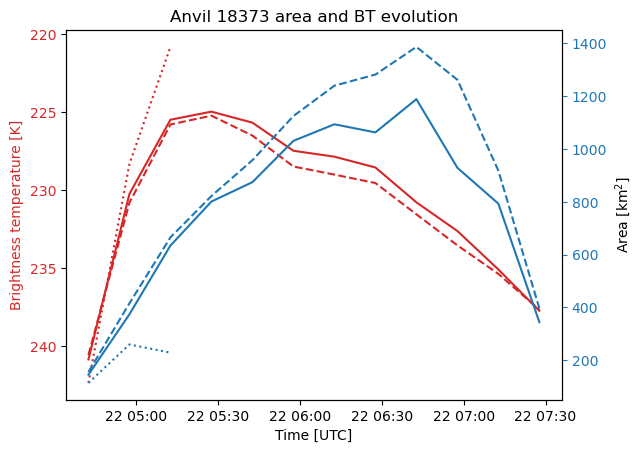

In [27]:
fig, ax1 = plt.subplots(1, 1)

ax1.plot(anvil_stats.thick_anvil_step_t, anvil_stats.thick_anvil_step_bt_mean, "C3-")
ax1.plot(anvil_stats.thin_anvil_step_t, anvil_stats.thin_anvil_step_bt_mean, "C3--")
ax1.plot(anvil_stats.core_step_t, anvil_stats.core_step_bt_mean, "C3:")

ax2 = ax1.twinx()
ax2.plot(anvil_stats.thick_anvil_step_t, anvil_stats.thick_anvil_step_area, "C0-")
ax2.plot(anvil_stats.thin_anvil_step_t, anvil_stats.thin_anvil_step_area, "C0--")
ax2.plot(anvil_stats.core_step_t, anvil_stats.core_step_area, "C0:")

ax1.invert_yaxis()
ax1.set_ylabel("Brightness temperature [K]", color="C3")
ax1.tick_params(axis='y', labelcolor="C3")

ax2.set_ylabel("Area [km$^2$]")
ax2.tick_params(axis='y', labelcolor="C0", color="C0")

ax1.set_xlabel("Time [UTC]")

ax1.set_title(f'Anvil {anvil} area and BT evolution')

## EarthCARE overpasses
There are to sets of EC overpass files, the first has one file for each overpass over the tracking domain, with all data regridded to the CPR ground track locations and to fixed height levels between 0 and 20 km. These are saved as netcdf datatrees with one group for each EC data product

In [29]:
overpass_files = sorted(list(overpass_path.glob("*.nc")))

In [33]:
overpass_dt = xr.open_datatree(overpass_files[-100])

In [34]:
overpass_dt

<xarray.DataTree>
Group: /
│   Dimensions:            (along_track: 8461, height: 200)
│   Coordinates:
│       time               (along_track) datetime64[ns] 68kB ...
│       latitude           (along_track) float64 68kB ...
│       longitude          (along_track) float64 68kB ...
│     * height             (height) float64 2kB 1.995e+04 1.985e+04 ... 150.0 50.0
│   Dimensions without coordinates: along_track
│   Data variables:
│       core_label         (along_track) int32 34kB ...
│       thick_anvil_label  (along_track) int32 34kB ...
│       thin_anvil_label   (along_track) int32 34kB ...
│   Attributes:
│       granules:              01772H 01773A 01773B
│       track_mask_filenames:  detected_dccs_MSG_S20240919_000000_E20240920_00000...
├── Group: /AC__TC__2B
│       Dimensions:                           (along_track: 8461, height: 200)
│       Coordinates:
│           time                              (along_track) datetime64[ns] 68kB ...
│           latitude                          (along_track) float64 68kB ...
│           longitude                         (along_track) float64 68kB ...
│       Dimensions without coordinates: along_track
│       Data variables:
│           synergetic_target_classification  (along_track, height) float64 14MB ...
│           CPR_ATLID_status                  (along_track, height) float64 14MB ...
│           quality_status                    (along_track, height) float64 14MB ...
│       Attributes:
│           File_Name:         ECA_EXBA_AC__TC__2B_20240919T212123Z_20250906T234401Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         AC__TC__2B
│           File_Version:      0001
├── Group: /ACM_CAP_2B
│       Dimensions:                                     (along_track: 8461, height: 200)
│       Coordinates:
│           time                                        (along_track) datetime64[ns] 68kB ...
│           latitude                                    (along_track) float64 68kB ...
│           longitude                                   (along_track) float64 68kB ...
│       Dimensions without coordinates: along_track
│       Data variables: (12/50)
│           tropopause_height                           (along_track) float32 34kB ...
│           synergy_status                              (along_track) float32 34kB ...
│           quality_status                              (along_track) float32 34kB ...
│           ice_extinction                              (along_track, height) float32 7MB ...
│           ice_riming_index                            (along_track, height) float32 7MB ...
│           ice_riming_index_error                      (along_track, height) float32 7MB ...
│           ...                                          ...
│           aerosol_mass_content_error                  (along_track, height) float32 7MB ...
│           aerosol_extinction                          (along_track, height) float32 7MB ...
│           aerosol_extinction_error                    (along_track, height) float32 7MB ...
│           aerosol_optical_depth                       (along_track) float32 34kB ...
│           aerosol_optical_depth_error                 (along_track) float32 34kB ...
│           CPR_doppler_velocity                        (along_track, height) float32 7MB ...
│       Attributes:
│           File_Name:         ECA_EXBA_ACM_CAP_2B_20240919T212123Z_20250907T194253Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         ACM_CAP_2B
│           File_Version:      0001
├── Group: /ACM_RT__2B
│       Dimensions:                                      (along_track: 8461,
│                                                         atmosphere_1d: 1,
│                                                         he

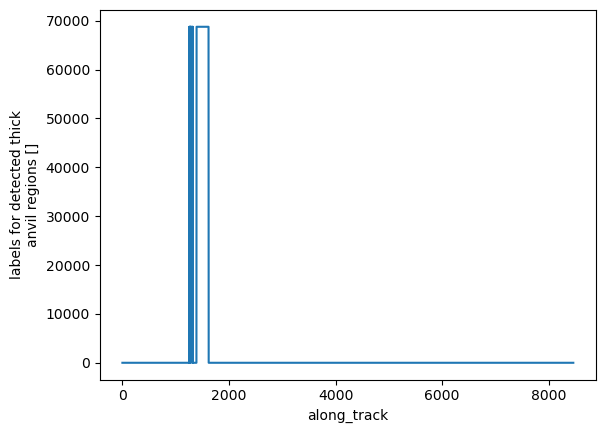

In [35]:
overpass_dt.thick_anvil_label.plot()

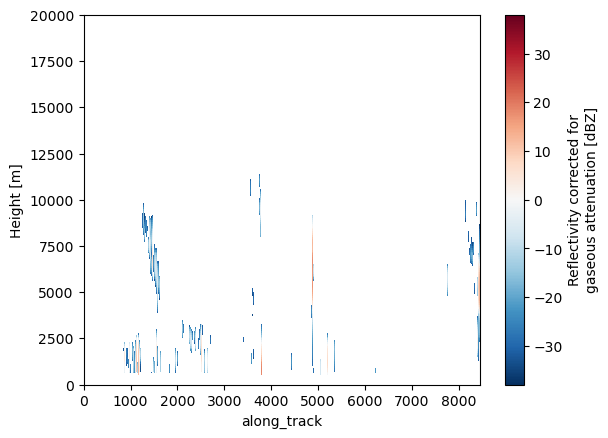

In [37]:
overpass_dt.CPR_FMR_2A.reflectivity_corrected.T.plot()

## Individual anvil overpasses
The regridded EarthCARE data is then sliced into chunks surrounding each individual anvil + 100km either side. These files also contain the properties relating to that anvil over it's lifetime

In [38]:
anvil_files = sorted(list(anvils_path.glob("*.nc")))

In [43]:
anvil_overpass_dt = xr.open_datatree(anvil_files[500]).load()

In [44]:
anvil_overpass_dt

<xarray.DataTree>
Group: /
│   Dimensions:                (along_track: 399, height: 200)
│   Coordinates:
│       time                   (along_track) datetime64[ns] 3kB 2024-09-01T17:50:...
│       latitude               (along_track) float64 3kB 17.53 17.52 ... 13.86 13.85
│       longitude              (along_track) float64 3kB -55.08 -55.08 ... -55.8
│     * height                 (height) float64 2kB 1.995e+04 1.985e+04 ... 50.0
│   Dimensions without coordinates: along_track
│   Data variables: (12/15)
│       core_label             (along_track) int32 2kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
│       thick_anvil_label      (along_track) int32 2kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
│       thin_anvil_label       (along_track) int32 2kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
│       anvil_id               int32 4B 34906
│       thick_anvil_is_valid   bool 1B False
│       thin_anvil_is_valid    bool 1B False
│       ...                     ...
│       anvil_core_count       int64 8B 119
│       anvil_core_intensity   float64 8B 2.081
│       anvil_max_area         float64 8B 9.773e+05
│       anvil_min_bt           float64 8B 188.4
│       anvil_lifetime_stage   <U7 28B 'growing'
│       min_overpass_distance  float64 8B 135.4
│   Attributes:
│       granules:              01490D 01490E
│       track_mask_filenames:  detected_dccs_MSG_S20240901_000000_E20240902_00000...
│       stats_file:            dcc_statistics_orcestra_S20240810_000000_E20241001...
├── Group: /AC__TC__2B
│       Dimensions:                           (along_track: 399, height: 200)
│       Coordinates:
│           time                              (along_track) datetime64[ns] 3kB 2024-0...
│           latitude                          (along_track) float64 3kB 17.53 ... 13.85
│           longitude                         (along_track) float64 3kB -55.08 ... -55.8
│       Dimensions without coordinates: along_track
│       Data variables:
│           synergetic_target_classification  (along_track, height) float64 638kB 13....
│           CPR_ATLID_status                  (along_track, height) float64 638kB 5.0...
│           quality_status                    (along_track, height) float64 638kB 9.3...
│       Attributes:
│           File_Name:         ECA_EXBA_AC__TC__2B_20240901T173736Z_20250906T234834Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         AC__TC__2B
│           File_Version:      0001
├── Group: /ACM_CAP_2B
│       Dimensions:                                     (along_track: 399, height: 200)
│       Coordinates:
│           time                                        (along_track) datetime64[ns] 3kB ...
│           latitude                                    (along_track) float64 3kB 17....
│           longitude                                   (along_track) float64 3kB -55...
│       Dimensions without coordinates: along_track
│       Data variables: (12/50)
│           tropopause_height                           (along_track) float32 2kB 1.6...
│           synergy_status                              (along_track) float32 2kB 0.0...
│           quality_status                              (along_track) float32 2kB 0.0...
│           ice_extinction                              (along_track, height) float32 319kB ...
│           ice_riming_index                            (along_track, height) float32 319kB ...
│           ice_riming_index_error                      (along_track, height) float32 319kB ...
│           ...                                          ...
│           aerosol_mass_content_error                  (along_track, height) float32 319kB ...
│           aerosol_extinction                          (along_track, height) float32 319kB ...
│           aerosol_extinction_error                    (along_track, height) float32 319kB ...
│           aerosol_optical_depth                       (along_track) float32 

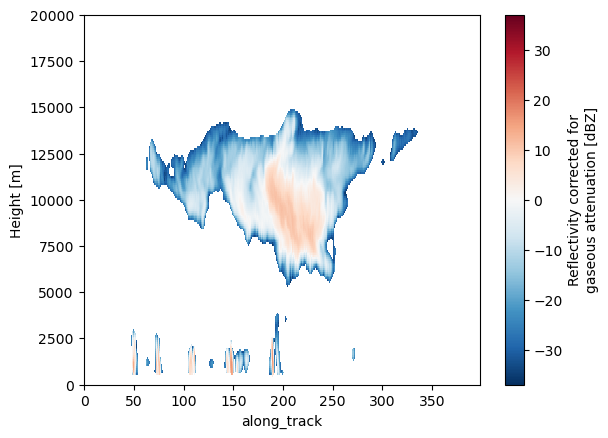

In [42]:
anvil_overpass_dt.CPR_FMR_2A.reflectivity_corrected.T.plot()

Text(0.5, 1.0, 'Anvil 18373 area and BT evolution')

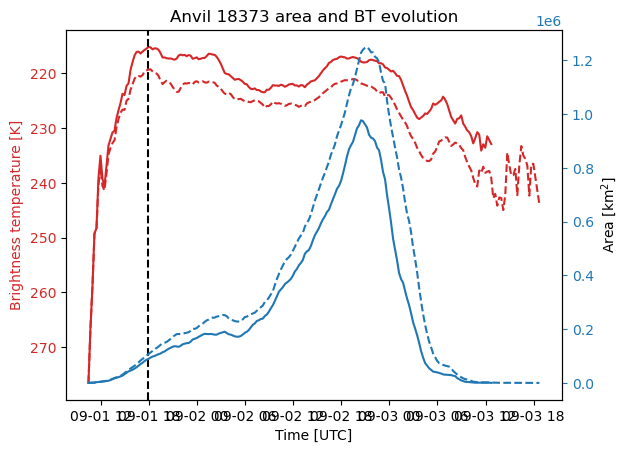

In [51]:
anvil_stats = anvil_overpass_dt.dcc_properties

fig, ax1 = plt.subplots(1, 1)

ax1.plot(anvil_stats.thick_anvil_step_t, anvil_stats.thick_anvil_step_bt_mean, "C3-")
ax1.plot(anvil_stats.thin_anvil_step_t, anvil_stats.thin_anvil_step_bt_mean, "C3--")
# ax1.plot(anvil_stats.core_step_t, anvil_stats.core_step_bt_mean, "C3:")

ax2 = ax1.twinx()
ax2.plot(anvil_stats.thick_anvil_step_t, anvil_stats.thick_anvil_step_area, "C0-")
ax2.plot(anvil_stats.thin_anvil_step_t, anvil_stats.thin_anvil_step_area, "C0--")
# ax2.plot(anvil_stats.core_step_t, anvil_stats.core_step_area, "C0:")

ax1.invert_yaxis()
ax1.set_ylabel("Brightness temperature [K]", color="C3")
ax1.tick_params(axis='y', labelcolor="C3")

ax2.set_ylabel("Area [km$^2$]")
ax2.tick_params(axis='y', labelcolor="C0", color="C0")

ax1.set_xlabel("Time [UTC]")

ax1.axvline(anvil_overpass_dt.mean_overpass_time.values, color="k", linestyle="--")

ax1.set_title(f'Anvil {anvil} area and BT evolution')

The black dashed line shows the time of overpass